# 06 — Raw Hazard EDA v2: Case-Study Selection

**Goal:** select a real RASFF case-study for the Regulatory Agent benchmark by starting from the original `hazards` field rather than the derived `Hazard_Type`.

### Analysis flow
`Origin × Category → inspect data completeness → screen pairs → inspect raw hazard strings → split multi-hazard records → light normalization → review aliases → Origin × Category × individual Hazard → time/seriousness → shortlist`

> RASFF notification counts describe reported notifications, not prevalence, exposure, or causal risk.

In [1]:
from pathlib import Path
import sys, re
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'rasff_core.py').exists():
    raise FileNotFoundError('Open this notebook from the RASFF_Rebuild folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rasff_core import load_prepared
df = load_prepared()

required = ['reference','date','origin','category','hazards','risk_decision','type']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print(f'Rows: {len(df):,}')
print(f'Date range: {df.date.min()} → {df.date.max()}')
display(df[['reference','date','origin','category','hazards','risk_decision']].head())

Rows: 27,397
Date range: 2020-01-02 09:24:48 → 2025-10-31 16:30:35


,reference,date,origin,category,hazards,risk_decision
0,2020.0001,2020-01-02 09:24:48,türkiye,fruits and vegetables,Aflatoxins B1,serious
1,2020.0004,2020-01-02 11:06:54,türkiye,fruits and vegetables,aflatoxin total,serious
2,2020.0007,2020-01-02 12:35:16,türkiye,fruits and vegetables,fosthiazate,serious
3,2020.0008,2020-01-02 12:35:36,poland,meat and meat products (other than poultry),Salmonella enteritidis,serious
4,2020.001,2020-01-02 13:42:42,china,food contact materials,formaldehyde migration,serious


## 1. Scope and raw-hazard quality

Start with food notifications with a known origin. Keep the original `hazards` field intact.

In [2]:
eda = df.loc[(df['type'].str.lower() == 'food') & df['origin'].ne('')].copy()
eda['year'] = eda['date'].dt.year
eda['hazard_raw'] = eda['hazards'].fillna('').astype(str).str.strip()
eda['hazard_missing'] = eda['hazard_raw'].eq('')

print(f'Food rows with known origin: {len(eda):,}')
print(f'Unique origins: {eda.origin.nunique():,}')
print(f'Unique categories: {eda.category.nunique():,}')
print(f'Missing raw hazards: {eda.hazard_missing.sum():,} ({eda.hazard_missing.mean():.1%})')
print(f'Unique non-empty raw hazard strings: {eda.loc[~eda.hazard_missing, "hazard_raw"].nunique():,}')

Food rows with known origin: 24,211
Unique origins: 588
Unique categories: 33
Missing raw hazards: 6,234 (25.7%)
Unique non-empty raw hazard strings: 2,485


## 2. Q1 — Which origin × category pairs are repeatedly reported?

First count notifications by `origin × category`. This is a support screen only; high counts do not mean a product/country is more unsafe.

In [3]:
origin_category = (
    eda.groupby(['origin','category'])
       .agg(
           notifications=('reference','nunique'),
           years=('year','nunique'),
           first_date=('date','min'),
           last_date=('date','max'),
           hazard_missing_share=('hazard_missing','mean'),
           serious_share=('target','mean'),
       )
       .reset_index()
       .sort_values(['notifications','years'], ascending=False)
)

display(origin_category.head(30))

,origin,category,notifications,years,first_date,last_date,hazard_missing_share,serious_share
1905,türkiye,fruits and vegetables,1810,6,2020-01-02 09:24:48,2025-10-29 10:59:01,0.010497,0.653039
1562,poland,poultry meat and poultry meat products,1138,6,2020-01-03 12:02:30,2025-10-31 15:11:07,0.033392,0.587873
1018,india,"nuts, nut products and seeds",503,6,2020-01-24 14:39:49,2025-10-30 12:21:25,0.053678,0.844930
2002,united states,"nuts, nut products and seeds",442,6,2020-01-08 12:41:36,2025-10-31 12:06:23,0.027149,0.889140
608,egypt,fruits and vegetables,364,6,2020-01-17 09:27:07,2025-10-31 14:04:20,0.041209,0.321429
1013,india,herbs and spices,352,6,2020-01-02 18:18:39,2025-10-29 09:15:36,0.156250,0.477273
1994,united states,"dietetic foods, food supplements and fortified...",287,6,2020-01-14 09:26:46,2025-10-31 16:01:46,0.710801,0.351916
1762,spain,fish and fish products,276,6,2020-02-04 10:40:20,2025-10-24 14:20:13,0.094203,0.742754
1490,pakistan,cereals and bakery products,269,6,2020-02-10 14:53:20,2025-10-27 14:56:16,0.048327,0.412639
1913,türkiye,"nuts, nut products and seeds",254,6,2020-01-07 14:17:07,2025-10-17 09:32:31,0.043307,0.921260


### Before filtering — inspect the top origin × category pairs

Before applying thresholds, inspect the top pairs together with hazard completeness. At this stage, **do not exclude anything yet**.

Useful columns:
- `notifications`: unique RASFF notifications
- `years`: number of calendar years represented
- `hazard_available_pct`: proportion with non-empty raw hazard information
- `hazard_missing_pct`: proportion without raw hazard information
- `serious_pct`: proportion carrying the recorded `serious` label

In [4]:
TOP_N_PAIRS = 30
pair_overview = origin_category.head(TOP_N_PAIRS).copy()
pair_overview['hazard_available_pct'] = ((1 - pair_overview['hazard_missing_share']) * 100).round(1)
pair_overview['hazard_missing_pct'] = (pair_overview['hazard_missing_share'] * 100).round(1)
pair_overview['serious_pct'] = (pair_overview['serious_share'] * 100).round(1)

display(pair_overview[[
    'origin','category','notifications','years',
    'hazard_available_pct','hazard_missing_pct','serious_pct',
    'first_date','last_date'
]])

,origin,category,notifications,years,hazard_available_pct,hazard_missing_pct,serious_pct,first_date,last_date
1905,türkiye,fruits and vegetables,1810,6,99.0,1.0,65.3,2020-01-02 09:24:48,2025-10-29 10:59:01
1562,poland,poultry meat and poultry meat products,1138,6,96.7,3.3,58.8,2020-01-03 12:02:30,2025-10-31 15:11:07
1018,india,"nuts, nut products and seeds",503,6,94.6,5.4,84.5,2020-01-24 14:39:49,2025-10-30 12:21:25
2002,united states,"nuts, nut products and seeds",442,6,97.3,2.7,88.9,2020-01-08 12:41:36,2025-10-31 12:06:23
608,egypt,fruits and vegetables,364,6,95.9,4.1,32.1,2020-01-17 09:27:07,2025-10-31 14:04:20
1013,india,herbs and spices,352,6,84.4,15.6,47.7,2020-01-02 18:18:39,2025-10-29 09:15:36
1994,united states,"dietetic foods, food supplements and fortified...",287,6,28.9,71.1,35.2,2020-01-14 09:26:46,2025-10-31 16:01:46
1762,spain,fish and fish products,276,6,90.6,9.4,74.3,2020-02-04 10:40:20,2025-10-24 14:20:13
1490,pakistan,cereals and bakery products,269,6,95.2,4.8,41.3,2020-02-10 14:53:20,2025-10-27 14:56:16
1913,türkiye,"nuts, nut products and seeds",254,6,95.7,4.3,92.1,2020-01-07 14:17:07,2025-10-17 09:32:31


## 3. Q2 — Which origin × category pairs have enough hazard information to inspect?

Only after inspecting the overview do we apply editable screening rules. These thresholds reduce the number of pairs to review; they are **not scientific cut-offs**.

In [5]:
MIN_PAIR_NOTIFICATIONS = 30
MIN_YEARS = 3
MAX_HAZARD_MISSING_SHARE = 0.50

pair_candidates = origin_category.loc[
    (origin_category.notifications >= MIN_PAIR_NOTIFICATIONS) &
    (origin_category.years >= MIN_YEARS) &
    (origin_category.hazard_missing_share <= MAX_HAZARD_MISSING_SHARE)
].copy()

display(pair_candidates.head(30))
print(f'Eligible origin × category pairs: {len(pair_candidates)}')

,origin,category,notifications,years,first_date,last_date,hazard_missing_share,serious_share
1905,türkiye,fruits and vegetables,1810,6,2020-01-02 09:24:48,2025-10-29 10:59:01,0.010497,0.653039
1562,poland,poultry meat and poultry meat products,1138,6,2020-01-03 12:02:30,2025-10-31 15:11:07,0.033392,0.587873
1018,india,"nuts, nut products and seeds",503,6,2020-01-24 14:39:49,2025-10-30 12:21:25,0.053678,0.844930
2002,united states,"nuts, nut products and seeds",442,6,2020-01-08 12:41:36,2025-10-31 12:06:23,0.027149,0.889140
608,egypt,fruits and vegetables,364,6,2020-01-17 09:27:07,2025-10-31 14:04:20,0.041209,0.321429
1013,india,herbs and spices,352,6,2020-01-02 18:18:39,2025-10-29 09:15:36,0.156250,0.477273
1762,spain,fish and fish products,276,6,2020-02-04 10:40:20,2025-10-24 14:20:13,0.094203,0.742754
1490,pakistan,cereals and bakery products,269,6,2020-02-10 14:53:20,2025-10-27 14:56:16,0.048327,0.412639
1913,türkiye,"nuts, nut products and seeds",254,6,2020-01-07 14:17:07,2025-10-17 09:32:31,0.043307,0.921260
1468,nigeria,"nuts, nut products and seeds",249,6,2020-01-09 16:20:43,2025-10-30 07:21:20,0.224900,0.734940


Eligible origin × category pairs: 114


## 4. Q3 — Inspect raw hazards before normalization

The default selects the highest-count eligible pair. Inspect whether the same hazard appears under multiple spellings and whether one notification contains multiple hazards.

In [6]:
SELECTED_ORIGIN = pair_candidates.iloc[0]['origin'] if len(pair_candidates) else None
SELECTED_CATEGORY = pair_candidates.iloc[0]['category'] if len(pair_candidates) else None

pair = eda.loc[(eda.origin == SELECTED_ORIGIN) & (eda.category == SELECTED_CATEGORY)].copy()

print('Selected:', SELECTED_ORIGIN, '|', SELECTED_CATEGORY)
print(f'Notifications: {pair.reference.nunique():,}')
print(f'Missing hazards: {pair.hazard_missing.mean():.1%}')

raw_counts = (
    pair.loc[~pair.hazard_missing]
        .groupby('hazard_raw')['reference'].nunique()
        .sort_values(ascending=False)
        .rename('notifications')
)
display(raw_counts.head(40))

display(pair.loc[~pair.hazard_missing,
    ['reference','date','hazard_raw','subject','risk_decision']]
    .sort_values('date', ascending=False).head(30))

Selected: türkiye | fruits and vegetables
Notifications: 1,810
Missing hazards: 1.0%


hazard_raw
Aflatoxin B1  ,aflatoxin total                              189
chlorpyrifos-methyl                                         163
ochratoxin A                                                152
acetamiprid                                                 116
chlorpyrifos-methyl  unauthorised substance                 104
chlorpyrifos                                                 96
prochloraz                                                   71
aflatoxin total                                              57
formetanate                                                  52
Aflatoxin B1                                                 46
flonicamid                                                   26
pyridaben                                                    22
imazalil                                                     19
Aflatoxins B1                                                19
buprofezin                                                   18
fosthiazate                  

,reference,date,hazard_raw,subject,risk_decision
27324,2025.8383,2025-10-29 10:59:01,"cypermethrin ,fenvalerate",Fenvalerate and Cypermethrin in fresh pomegran...,serious
27286,2025.8274,2025-10-27 11:50:55,ochratoxin A,Ochratoxin A in dried figs from Turkey,potentially serious
27284,2025.8271,2025-10-27 11:37:34,ochratoxin A,Ochratoxin A in dried organic figs from Turkey,potentially serious
27266,2025.8229,2025-10-24 12:56:21,aflatoxin total,Aflatoxins in dried figs from Türkiye,serious
27208,2025.8121,2025-10-22 09:50:39,ochratoxin A,Ochratoxin A in dried fig cubes from Turkey,serious
27205,2025.8114,2025-10-21 18:05:12,"Aflatoxin B1 ,aflatoxin total ,ochratoxin A",Aflatoxins and ochratoxin A in dried figs from...,serious
27184,2025.8068,2025-10-20 17:29:13,acetamiprid,Acetamiprid Grapes from Turkey,serious
27179,2025.8063,2025-10-20 16:43:05,acetamiprid,acetamiprid on dried raisins from Türkiye,serious
27133,2025.7984,2025-10-17 10:01:10,ochratoxin A,Ochratoxin A in dried figs from Türkiye,serious
27109,2025.7949,2025-10-16 12:04:39,fosthiazate,Fosthiazate in fresh domatoes from Türkiye,serious


## 5. Q4 — Split and normalize individual hazards

The raw `hazards` field may contain several hazards in one notification, for example:

`Aflatoxin B1 ,aflatoxin total ,ochratoxin A`

Treating this as one unique string hides the individual hazards. For EDA we therefore:

1. preserve `hazard_raw`,
2. split comma-separated entries,
3. explode to one `notification × hazard item` row,
4. apply only light formatting normalization,
5. inspect variants before making semantic aliases.

A notification may contain multiple hazards, so hazard counts are **not additive** to the total number of notifications.

In [19]:
hazard_long = eda.loc[~eda['hazard_missing']].copy()

# The supplied snapshot commonly stores multiple hazards separated by commas.
hazard_long["hazard_list"] = (
    hazard_long["hazard_raw"]
    .str.split(r"\s+,", regex=True)
)
hazard_long = hazard_long.explode('hazard_list')
hazard_long['hazard_item_raw'] = hazard_long['hazard_list'].fillna('').astype(str).str.strip()
hazard_long = hazard_long.loc[hazard_long['hazard_item_raw'].ne('')].copy()

print('Original notifications with hazard information:',
      f"{eda.loc[~eda.hazard_missing, 'reference'].nunique():,}")
print('Notification × hazard rows after exploding:', f'{len(hazard_long):,}')

display(hazard_long[['reference','origin','category','hazard_raw','hazard_item_raw']].head(20))

Original notifications with hazard information: 17,977
Notification × hazard rows after exploding: 23,354


,reference,origin,category,hazard_raw,hazard_item_raw
0,2020.0001,türkiye,fruits and vegetables,Aflatoxins B1,Aflatoxins B1
1,2020.0004,türkiye,fruits and vegetables,aflatoxin total,aflatoxin total
2,2020.0007,türkiye,fruits and vegetables,fosthiazate,fosthiazate
3,2020.0008,poland,meat and meat products (other than poultry),Salmonella enteritidis,Salmonella enteritidis
6,2020.0012,indonesia,"nuts, nut products and seeds",sulphur dioxide (SO2),sulphur dioxide (SO2)
8,2020.0016,india,herbs and spices,Salmonella spp.,Salmonella spp.
10,2020.0029,poland,poultry meat and poultry meat products,Salmonella Enteritidis,Salmonella Enteritidis
13,2020.0034,united kingdom,"nuts, nut products and seeds",Aflatoxins B1,Aflatoxins B1
14,2020.0035,türkiye,fruits and vegetables,Aflatoxin B1,Aflatoxin B1
18,2020.004,poland,poultry meat and poultry meat products,Salmonella enteritidis,Salmonella enteritidis


In [20]:
def normalize_hazard_item(value):
    """Formatting cleanup only; does not merge scientifically different hazards."""
    if pd.isna(value):
        return ''
    s = str(value).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    s = s.strip(' ,;:')
    return s

hazard_long['hazard_clean'] = hazard_long['hazard_item_raw'].map(normalize_hazard_item)

print('Unique hazard items before cleaning:', hazard_long['hazard_item_raw'].nunique())
print('Unique hazard items after light cleaning:', hazard_long['hazard_clean'].nunique())

Unique hazard items before cleaning: 1565
Unique hazard items after light cleaning: 1560


### Inspect individual hazards within the selected pair

This is the first table that directly answers: **within this origin × category pair, which individual hazards are most frequently reported?**

In [22]:
pair_hazards = hazard_long.loc[
    (hazard_long['origin'] == SELECTED_ORIGIN) &
    (hazard_long['category'] == SELECTED_CATEGORY)
].copy()

hazard_counts = (
    pair_hazards.groupby('hazard_clean')['reference']
                .nunique()
                .sort_values(ascending=False)
                .rename('notifications')
                .reset_index()
)

display(hazard_counts.head(40))

,hazard_clean,notifications
0,aflatoxin total,278
1,aflatoxin b1,266
2,chlorpyrifos-methyl,242
3,acetamiprid,193
4,ochratoxin a,180
5,chlorpyrifos,134
6,chlorpyrifos-methyl unauthorised substance,114
7,prochloraz,108
8,formetanate,73
9,pyridaben,71


### Review variants before merging

Use a keyword to inspect whether one hazard is fragmented across spelling variants. This helper **does not merge anything**. The review runs across all food notifications so the alias decision is based on the dataset's overall recording pattern, not only one selected pair.

In [23]:
KEYWORD = 'aflatoxin'  # change to e.g. salmonella, chlorpyrifos, ochratoxin

keyword_review = (
    hazard_long.loc[
        hazard_long['hazard_clean'].str.contains(KEYWORD, case=False, na=False)
    ]
    .groupby('hazard_clean')['reference']
    .nunique()
    .sort_values(ascending=False)
    .rename('notifications')
    .reset_index()
)

display(keyword_review.head(50))

,hazard_clean,notifications
0,aflatoxin b1,2032
1,aflatoxin total,1576
2,aflatoxins b1,178
3,aflatoxin,122
4,aflatoxins,74
5,"bacillus cereus presumptive,aflatoxin total",1


### Audit major hazard families before defining aliases

Before creating the final alias mapping, inspect the major hazard families
that appear repeatedly in the dataset.

The purpose is to distinguish:

- simple spelling or formatting variants that can be safely merged,
- regulatory descriptors attached to the same substance,
- scientifically distinct hazards that must remain separate.

This step does not modify the data.
It only identifies candidates for manual normalization.

In [24]:
HAZARD_FAMILIES_TO_REVIEW = [
    "aflatoxin",
    "salmonella",
    "chlorpyrifos",
    "ochratoxin",
    "listeria",
]

for keyword in HAZARD_FAMILIES_TO_REVIEW:

    print("\n" + "=" * 70)
    print(f"REVIEW: {keyword.upper()}")
    print("=" * 70)

    family_review = (
        hazard_long.loc[
            hazard_long["hazard_clean"].str.contains(
                keyword,
                case=False,
                na=False
            )
        ]
        .groupby("hazard_clean")["reference"]
        .nunique()
        .sort_values(ascending=False)
        .rename("notifications")
        .reset_index()
    )

    display(family_review.head(30))


REVIEW: AFLATOXIN


,hazard_clean,notifications
0,aflatoxin b1,2032
1,aflatoxin total,1576
2,aflatoxins b1,178
3,aflatoxin,122
4,aflatoxins,74
5,"bacillus cereus presumptive,aflatoxin total",1



REVIEW: SALMONELLA


,hazard_clean,notifications
0,salmonella enteritidis,1036
1,salmonella spp.,680
2,salmonella,468
3,salmonella infantis,377
4,salmonella spp,242
5,salmonella typhimurium,159
6,salmonella newport,125
7,salmonella group c,39
8,salmonella agona,32
9,salmonella minnesota,30



REVIEW: CHLORPYRIFOS


,hazard_clean,notifications
0,chlorpyrifos,642
1,chlorpyrifos unauthorised substance,310
2,chlorpyrifos-methyl,282
3,chlorpyrifos-methyl unauthorised substance,126
4,"chlorpyrifos unauthorised substance,clothianidin",18
5,"carbendazim unauthorised substance,chlorpyrifos",17
6,"chlorpyrifos unauthorised substance,dimethoate",11
7,"chlorpyrifos-methyl unauthorised substance,fen...",8
8,"chlorpyrifos unauthorised substance,imidacloprid",6
9,"chlorpyrifos unauthorised substance,tricyclazo...",6



REVIEW: OCHRATOXIN


,hazard_clean,notifications
0,ochratoxin a,491



REVIEW: LISTERIA


,hazard_clean,notifications
0,listeria monocytogenes,742
1,listeria spp,16
2,listeria,8
3,listeria innocua,2
4,escherichia coli shigatoxin-producing suspicio...,1
5,"bacillus cereus presumptive,listeria monocytog...",1
6,"enterobacteriaceae high count,listeria monocyt...",1


In [25]:
suspect = eda.loc[
    eda["hazard_raw"].str.contains(
        "typhimurium monophasic",
        case=False,
        na=False
    ),
    ["reference", "hazard_raw"]
].drop_duplicates()

display(suspect.head(30))

,reference,hazard_raw
88,2020.0167,Salmonella typhimurium monophasic
188,2020.0372,"Salmonella typhimurium monophasic (4, 5:i:-)"
613,2020.1083,"Salmonella typhimurium monophasic (4, 5:i:-)"
669,2020.1161,"Salmonella typhimurium monophasic (4, 5:i:-)"
890,2020.1589,"Salmonella typhimurium monophasic (4, 5:i:-)"
1130,2020.2018,"Salmonella typhimurium monophasic (4, 5:i:-)"
1294,2020.2319,Salmonella typhimurium monophasic
1963,2020.3378,Salmonella typhimurium monophasic
1993,2020.3421,"Salmonella typhimurium monophasic (4, 5:i:-)"
2331,2020.3951,"Salmonella typhimurium monophasic (4, 5:i:-)"


### Conservative alias mapping

Based on the current aflatoxin review, only obvious singular/plural recording variants are merged:

- `aflatoxins b1` → `aflatoxin b1`
- `aflatoxins` → `aflatoxin`

`aflatoxin b1`, `aflatoxin total`, and unspecified `aflatoxin` remain separate because they do not carry identical information.

Add future aliases only after reviewing the raw strings.

In [27]:
HAZARD_ALIASES = {
    # Aflatoxin
    "aflatoxins b1": "aflatoxin b1",
    "aflatoxins": "aflatoxin",

    # Salmonella
    "salmonella spp": "salmonella spp.",
    "salmonella typhimurium monophasic (4, 5:i:-)":
        "salmonella typhimurium monophasic",

    # Chlorpyrifos
    "chlorpyrifos unauthorised substance": "chlorpyrifos",
    "chlorpyrifos-methyl unauthorised substance": "chlorpyrifos-methyl",
}

hazard_long['hazard_normalized'] = hazard_long['hazard_clean'].replace(HAZARD_ALIASES)

for keyword in ["aflatoxin", "salmonella", "chlorpyrifos"]:
    print("\n" + "=" * 70)
    print(f"NORMALIZED: {keyword.upper()}")
    print("=" * 70)

    review = (
        hazard_long.loc[
            hazard_long["hazard_normalized"].str.contains(
                keyword, case=False, na=False
            )
        ]
        .groupby("hazard_normalized")["reference"]
        .nunique()
        .sort_values(ascending=False)
        .rename("notifications")
        .reset_index()
    )

    display(review.head(30))


NORMALIZED: AFLATOXIN


,hazard_normalized,notifications
0,aflatoxin b1,2145
1,aflatoxin total,1576
2,aflatoxin,196
3,"bacillus cereus presumptive,aflatoxin total",1



NORMALIZED: SALMONELLA


,hazard_normalized,notifications
0,salmonella enteritidis,1036
1,salmonella spp.,917
2,salmonella,468
3,salmonella infantis,377
4,salmonella typhimurium,159
5,salmonella newport,125
6,salmonella group c,39
7,salmonella typhimurium monophasic,38
8,salmonella agona,32
9,salmonella minnesota,30



NORMALIZED: CHLORPYRIFOS


,hazard_normalized,notifications
0,chlorpyrifos,949
1,chlorpyrifos-methyl,408
2,"chlorpyrifos unauthorised substance,clothianidin",18
3,"carbendazim unauthorised substance,chlorpyrifos",17
4,"chlorpyrifos unauthorised substance,dimethoate",11
5,"chlorpyrifos-methyl unauthorised substance,fen...",8
6,"chlorpyrifos unauthorised substance,lambda-cyh...",6
7,"chlorpyrifos unauthorised substance,tricyclazo...",6
8,"carbendazim unauthorised substance,chlorpyrifo...",6
9,"chlorpyrifos unauthorised substance,imidacloprid",6


## 6. Q5 — Rank origin × category × individual normalized hazard patterns

Now combine the three dimensions using the exploded hazard table. Counts use unique `reference` values so the same notification is not counted twice for the same normalized hazard.

In [28]:
three_way = (
    hazard_long.groupby(['origin','category','hazard_normalized'])
    .agg(
        notifications=('reference','nunique'),
        years=('year','nunique'),
        first_date=('date','min'),
        last_date=('date','max'),
        serious_share=('target','mean'),
    )
    .reset_index()
)

pair_meta = origin_category[['origin','category','notifications','hazard_missing_share']].rename(
    columns={'notifications':'origin_category_total'}
)
three_way = three_way.merge(pair_meta, on=['origin','category'], how='left')
three_way['share_within_origin_category'] = (
    three_way['notifications'] / three_way['origin_category_total']
)
three_way = three_way.sort_values(
    ['notifications','years','share_within_origin_category'], ascending=False
)

display(three_way.head(40))

print('\nSelected pair — normalized individual hazards')
display(
    three_way.loc[
        (three_way.origin == SELECTED_ORIGIN) &
        (three_way.category == SELECTED_CATEGORY)
    ].head(30)
)

,origin,category,hazard_normalized,notifications,years,first_date,last_date,serious_share,origin_category_total,hazard_missing_share,share_within_origin_category
5480,poland,poultry meat and poultry meat products,salmonella enteritidis,490,6,2020-01-03 12:02:30,2025-10-28 14:05:31,0.898990,1138,0.033392,0.430580
7646,united states,"nuts, nut products and seeds",aflatoxin b1,356,6,2020-01-08 15:18:11,2025-10-31 12:06:23,0.931507,442,0.027149,0.805430
6894,türkiye,fruits and vegetables,chlorpyrifos-methyl,356,6,2020-11-13 14:39:57,2025-04-22 10:40:56,0.244382,1810,0.010497,0.196685
6862,türkiye,fruits and vegetables,aflatoxin b1,297,6,2020-01-02 09:24:48,2025-10-21 18:05:12,0.940199,1810,0.010497,0.164088
6863,türkiye,fruits and vegetables,aflatoxin total,278,6,2020-01-02 11:06:54,2025-10-24 12:56:21,0.956835,1810,0.010497,0.153591
7647,united states,"nuts, nut products and seeds",aflatoxin total,260,6,2020-01-08 15:18:11,2025-10-31 12:06:23,0.919231,442,0.027149,0.588235
3461,india,"nuts, nut products and seeds",ethylene oxide,212,6,2020-10-20 12:47:44,2025-06-06 11:54:36,0.966981,503,0.053678,0.421471
5489,poland,poultry meat and poultry meat products,salmonella infantis,203,6,2020-01-07 14:27:28,2025-10-23 10:39:32,0.221675,1138,0.033392,0.178383
6859,türkiye,fruits and vegetables,acetamiprid,193,6,2020-01-20 12:06:30,2025-10-20 17:29:13,0.891192,1810,0.010497,0.106630
102,argentina,"nuts, nut products and seeds",aflatoxin b1,188,6,2020-02-05 13:04:34,2025-10-29 14:38:17,0.904762,202,0.009901,0.930693



Selected pair — normalized individual hazards


,origin,category,hazard_normalized,notifications,years,first_date,last_date,serious_share,origin_category_total,hazard_missing_share,share_within_origin_category
6894,türkiye,fruits and vegetables,chlorpyrifos-methyl,356,6,2020-11-13 14:39:57,2025-04-22 10:40:56,0.244382,1810,0.010497,0.196685
6862,türkiye,fruits and vegetables,aflatoxin b1,297,6,2020-01-02 09:24:48,2025-10-21 18:05:12,0.940199,1810,0.010497,0.164088
6863,türkiye,fruits and vegetables,aflatoxin total,278,6,2020-01-02 11:06:54,2025-10-24 12:56:21,0.956835,1810,0.010497,0.153591
6859,türkiye,fruits and vegetables,acetamiprid,193,6,2020-01-20 12:06:30,2025-10-20 17:29:13,0.891192,1810,0.010497,0.106630
6981,türkiye,fruits and vegetables,ochratoxin a,180,6,2020-01-17 16:38:11,2025-10-27 11:50:55,0.900000,1810,0.010497,0.099448
6886,türkiye,fruits and vegetables,chlorpyrifos,150,5,2020-01-20 12:06:30,2024-10-14 13:36:47,0.220000,1810,0.010497,0.082873
6996,türkiye,fruits and vegetables,prochloraz,108,6,2020-02-03 09:47:32,2025-07-02 13:01:32,0.907407,1810,0.010497,0.059669
6956,türkiye,fruits and vegetables,formetanate,73,6,2020-01-22 12:08:30,2025-09-16 11:25:07,1.000000,1810,0.010497,0.040331
7002,türkiye,fruits and vegetables,pyridaben,71,2,2020-01-14 15:40:23,2021-08-26 14:57:22,0.915493,1810,0.010497,0.039227
6876,türkiye,fruits and vegetables,buprofezin,62,5,2020-02-03 16:18:00,2024-12-19 17:26:35,0.500000,1810,0.010497,0.034254


## 7. Q6 — Screen repeated individual-hazard candidates

These are editable benchmark-discovery thresholds, not epidemiological cut-offs.

In [29]:
MIN_HAZARD_NOTIFICATIONS = 15
MIN_HAZARD_YEARS = 3
MIN_WITHIN_PAIR_SHARE = 0.10

hazard_candidates = three_way.loc[
    (three_way.notifications >= MIN_HAZARD_NOTIFICATIONS) &
    (three_way.years >= MIN_HAZARD_YEARS) &
    (three_way.share_within_origin_category >= MIN_WITHIN_PAIR_SHARE)
].copy()

display(hazard_candidates.head(30))
print(f'Individual-hazard candidate patterns: {len(hazard_candidates)}')

,origin,category,hazard_normalized,notifications,years,first_date,last_date,serious_share,origin_category_total,hazard_missing_share,share_within_origin_category
5480,poland,poultry meat and poultry meat products,salmonella enteritidis,490,6,2020-01-03 12:02:30,2025-10-28 14:05:31,0.898990,1138,0.033392,0.430580
7646,united states,"nuts, nut products and seeds",aflatoxin b1,356,6,2020-01-08 15:18:11,2025-10-31 12:06:23,0.931507,442,0.027149,0.805430
6894,türkiye,fruits and vegetables,chlorpyrifos-methyl,356,6,2020-11-13 14:39:57,2025-04-22 10:40:56,0.244382,1810,0.010497,0.196685
6862,türkiye,fruits and vegetables,aflatoxin b1,297,6,2020-01-02 09:24:48,2025-10-21 18:05:12,0.940199,1810,0.010497,0.164088
6863,türkiye,fruits and vegetables,aflatoxin total,278,6,2020-01-02 11:06:54,2025-10-24 12:56:21,0.956835,1810,0.010497,0.153591
7647,united states,"nuts, nut products and seeds",aflatoxin total,260,6,2020-01-08 15:18:11,2025-10-31 12:06:23,0.919231,442,0.027149,0.588235
3461,india,"nuts, nut products and seeds",ethylene oxide,212,6,2020-10-20 12:47:44,2025-06-06 11:54:36,0.966981,503,0.053678,0.421471
5489,poland,poultry meat and poultry meat products,salmonella infantis,203,6,2020-01-07 14:27:28,2025-10-23 10:39:32,0.221675,1138,0.033392,0.178383
6859,türkiye,fruits and vegetables,acetamiprid,193,6,2020-01-20 12:06:30,2025-10-20 17:29:13,0.891192,1810,0.010497,0.106630
102,argentina,"nuts, nut products and seeds",aflatoxin b1,188,6,2020-02-05 13:04:34,2025-10-29 14:38:17,0.904762,202,0.009901,0.930693


Individual-hazard candidate patterns: 126


## 8. Q7 — Is a selected pattern persistent over time?

Choose a candidate explicitly. The default uses the highest-count candidate overall; edit the three variables if another case is more scientifically useful.

Case: poland | poultry meat and poultry meat products | salmonella enteritidis


,year,notifications
0,2020,159
1,2021,135
2,2022,70
3,2023,53
4,2024,31
5,2025,42


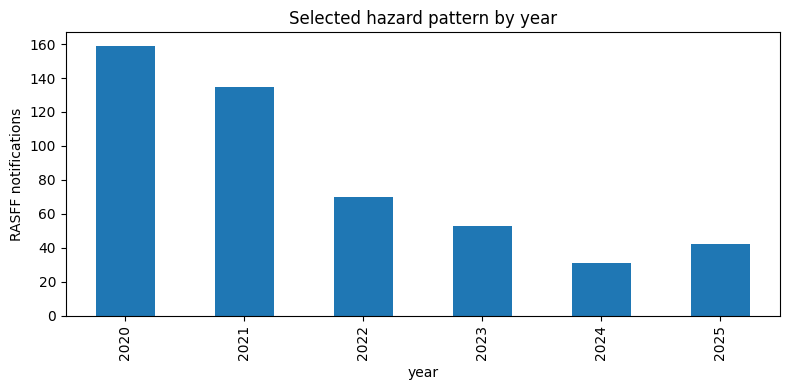

In [30]:
if len(hazard_candidates):
    default_case = hazard_candidates.iloc[0]
    CASE_ORIGIN = default_case['origin']
    CASE_CATEGORY = default_case['category']
    CASE_HAZARD = default_case['hazard_normalized']
else:
    CASE_ORIGIN = CASE_CATEGORY = CASE_HAZARD = None

case = hazard_long.loc[
    (hazard_long.origin == CASE_ORIGIN) &
    (hazard_long.category == CASE_CATEGORY) &
    (hazard_long.hazard_normalized == CASE_HAZARD)
].copy()

print('Case:', CASE_ORIGIN, '|', CASE_CATEGORY, '|', CASE_HAZARD)

yearly = case.groupby('year')['reference'].nunique().rename('notifications').reset_index()
display(yearly)

if len(yearly):
    ax = yearly.plot(x='year', y='notifications', kind='bar', legend=False,
                     figsize=(8,4), title='Selected hazard pattern by year')
    ax.set_ylabel('RASFF notifications')
    plt.tight_layout()
    plt.show()

## 9. Q8 — Bring `Hazard_Type` back only as a cross-check

`Hazard_Type` was useful in Project 002 for modeling/visualization, but it should not decide the exact hazard case-study. Here it is only descriptive context.

In [31]:
if 'Hazard_Type' in case.columns:
    display(
        case.groupby('Hazard_Type')['reference'].nunique()
            .sort_values(ascending=False)
            .rename('notifications')
    )
else:
    print('Hazard_Type is not present — no cross-check needed.')

Hazard_Type
Microbiological    488
Others               2
Name: notifications, dtype: int64

## 10. Q9 — Build a shortlist for Regulatory Agent feasibility checking

Do **not** automatically choose the final benchmark case from count alone. Review the top candidates for:

- data support and years,
- raw hazard completeness,
- hazard specificity and normalization quality,
- identifiable EU legislation / official guidance,
- usefulness for RAG,
- usefulness for RASFF search/data-analysis tools,
- potential for multi-step investigation,
- interpretability without implying notification count = underlying risk.

The final 2–3 cases should be checked against official regulatory sources before freezing the 10-question benchmark.

In [32]:
shortlist = hazard_candidates.head(20).copy()

# Descriptive cross-check only
if 'Hazard_Type' in hazard_long.columns:
    type_mode = (
        hazard_long.groupby(['origin','category','hazard_normalized'])['Hazard_Type']
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else '')
        .rename('derived_hazard_type')
        .reset_index()
    )
    shortlist = shortlist.merge(type_mode, on=['origin','category','hazard_normalized'], how='left')

shortlist['raw_hazard_reviewed'] = False
shortlist['regulatory_link_checked'] = False
shortlist['notes'] = ''

display(shortlist)

out = ROOT / 'artifacts' / 'regulatory_agent_individual_hazard_candidates.csv'
shortlist.to_csv(out, index=False)
print('Saved:', out)

,origin,category,hazard_normalized,notifications,years,first_date,last_date,serious_share,origin_category_total,hazard_missing_share,share_within_origin_category,derived_hazard_type,raw_hazard_reviewed,regulatory_link_checked,notes
0,poland,poultry meat and poultry meat products,salmonella enteritidis,490,6,2020-01-03 12:02:30,2025-10-28 14:05:31,0.898990,1138,0.033392,0.430580,Microbiological,False,False,
1,united states,"nuts, nut products and seeds",aflatoxin b1,356,6,2020-01-08 15:18:11,2025-10-31 12:06:23,0.931507,442,0.027149,0.805430,Mycotoxins,False,False,
2,türkiye,fruits and vegetables,chlorpyrifos-methyl,356,6,2020-11-13 14:39:57,2025-04-22 10:40:56,0.244382,1810,0.010497,0.196685,Chemical/Contaminants,False,False,
3,türkiye,fruits and vegetables,aflatoxin b1,297,6,2020-01-02 09:24:48,2025-10-21 18:05:12,0.940199,1810,0.010497,0.164088,Mycotoxins,False,False,
4,türkiye,fruits and vegetables,aflatoxin total,278,6,2020-01-02 11:06:54,2025-10-24 12:56:21,0.956835,1810,0.010497,0.153591,Mycotoxins,False,False,
5,united states,"nuts, nut products and seeds",aflatoxin total,260,6,2020-01-08 15:18:11,2025-10-31 12:06:23,0.919231,442,0.027149,0.588235,Mycotoxins,False,False,
6,india,"nuts, nut products and seeds",ethylene oxide,212,6,2020-10-20 12:47:44,2025-06-06 11:54:36,0.966981,503,0.053678,0.421471,Chemical/Contaminants,False,False,
7,poland,poultry meat and poultry meat products,salmonella infantis,203,6,2020-01-07 14:27:28,2025-10-23 10:39:32,0.221675,1138,0.033392,0.178383,Microbiological,False,False,
8,türkiye,fruits and vegetables,acetamiprid,193,6,2020-01-20 12:06:30,2025-10-20 17:29:13,0.891192,1810,0.010497,0.106630,Chemical/Contaminants,False,False,
9,argentina,"nuts, nut products and seeds",aflatoxin b1,188,6,2020-02-05 13:04:34,2025-10-29 14:38:17,0.904762,202,0.009901,0.930693,Mycotoxins,False,False,


Saved: c:\Users\SAMSUNG\Desktop\rasff_risk_predictor\RASFF_Rebuild\artifacts\regulatory_agent_individual_hazard_candidates.csv


## 10. Q10 — What actual products drive the strongest origin × category × hazard candidates?

Category labels can be broad. Before freezing a benchmark case, drill down to the original `subject` text to see which actual products repeatedly appear within the strongest `origin × category × hazard` patterns.

This is a **case-selection diagnostic**, not a new normalization layer. `subject` is intentionally kept as raw text because it may contain product wording, hazard details, regulatory language, or other notification-specific information. We therefore use it to inspect recurring product signals rather than treating each full subject string as a clean product taxonomy.


In [ ]:
# Subject drill-down for representative high-ranking candidates
if 'subject' not in hazard_long.columns:
    raise ValueError("'subject' is required for the product-level drill-down.")

# Keep a small, diverse set of strong candidates rather than only the global top rows.
SUBJECT_CASES = [
    ('poland', 'poultry meat and poultry meat products', 'salmonella enteritidis'),
    ('united states', 'nuts, nut products and seeds', 'aflatoxin b1'),
    ('türkiye', 'fruits and vegetables', 'chlorpyrifos-methyl'),
    ('türkiye', 'fruits and vegetables', 'aflatoxin b1'),
    ('india', 'nuts, nut products and seeds', 'ethylene oxide'),
]

subject_drilldown_parts = []

for origin, category, hazard in SUBJECT_CASES:
    case = hazard_long.loc[
        hazard_long['origin'].eq(origin)
        & hazard_long['category'].eq(category)
        & hazard_long['hazard_normalized'].eq(hazard)
    ].copy()

    case['subject_raw'] = case['subject'].fillna('').astype(str).str.strip()
    case['subject_missing'] = case['subject_raw'].eq('')

    total_notifications = case['reference'].nunique()
    missing_subjects = case.loc[case['subject_missing'], 'reference'].nunique()

    subject_counts = (
        case.loc[~case['subject_missing']]
        .groupby('subject_raw')['reference']
        .nunique()
        .sort_values(ascending=False)
        .rename('notifications')
        .reset_index()
    )

    if total_notifications:
        subject_counts['share_within_case'] = subject_counts['notifications'] / total_notifications
    else:
        subject_counts['share_within_case'] = np.nan

    subject_counts.insert(0, 'hazard_normalized', hazard)
    subject_counts.insert(0, 'category', category)
    subject_counts.insert(0, 'origin', origin)

    print('\n' + '=' * 90)
    print(f'{origin.upper()} | {category} | {hazard}')
    print(f'Notifications in case: {total_notifications:,}')
    print(f'Missing subject: {missing_subjects:,} ({missing_subjects / total_notifications:.1%})' if total_notifications else 'Missing subject: n/a')
    display(subject_counts.head(20))

    subject_drilldown_parts.append(subject_counts)

subject_drilldown = pd.concat(subject_drilldown_parts, ignore_index=True)

# Save the raw-subject drill-down for manual review during benchmark case selection.
subject_out = ROOT / 'artifacts' / 'regulatory_agent_subject_drilldown.csv'
subject_drilldown.to_csv(subject_out, index=False)
print('\nSaved:', subject_out)


### How to read the subject drill-down

Look for a candidate where a recognizable product pattern appears repeatedly and can support a concrete regulatory investigation. A broad category may split into very different products, so the next benchmark case should be defined only after this inspection.

Do **not** sum subject shares as if subjects were standardized product classes. The strings are raw notification text and semantically similar products may appear under different wording. Use this table to identify patterns for manual review; product normalization can be added later only if it materially changes case selection.


## Interpretation guardrails

1. **Notification count ≠ prevalence or true risk.** RASFF records notified events, not all products, imports, inspections or exposures.
2. **Origin ≠ causation.** Trade volume, border-control intensity, targeted sampling and reporting practice can affect counts.
3. **Raw `hazards` comes first.** `Hazard_Type` is used only after candidate discovery.
4. **Multi-hazard notifications are exploded for analysis.** One notification can therefore contribute to more than one hazard.
5. **Counts use unique `reference` within each hazard** to avoid duplicate counting of the same notification/hazard combination.
6. **Normalization is conservative and auditable.** Scientifically different hazards are not merged merely for convenience.
7. **Missing hazards remain a data-quality limitation.** Blank does not mean no hazard existed.
8. **This notebook selects benchmark cases; it does not estimate causal or population-level food-safety risk.**

### Next step
Run the notebook and review:
- `pair_overview`
- `pair_candidates`
- `hazard_counts` for the selected pair
- `keyword_review` for important hazard families
- `three_way`
- `hazard_candidates`

Then verify 2–3 promising cases against official EU regulatory evidence before designing the 10-question Prompt → RAG → Tools → Agent benchmark.